# Test beersheba on MC 

In [24]:
import sys,os,os.path

from glob import glob
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

sys.path.append("/gluster/data/next/software/IC_john/")
sys.path.append(os.path.expanduser('~/code/eol_hsrl_python'))
os.environ['ICTDIR']='/gluster/data/next/software/IC_john/'

from invisible_cities.io.dst_io        import load_dst, load_dsts
from invisible_cities.cities.beersheba import cut_over_Q
from invisible_cities.cities.beersheba import drop_isolated 
from invisible_cities.cities.beersheba import deconvolve_signal
from invisible_cities.reco.deconv_functions import deconvolution_input
from invisible_cities.reco.deconv_functions import InterpolationMethod
from invisible_cities.cities.beersheba import DeconvolutionMode
from invisible_cities.cities.beersheba          import CutType
from invisible_cities.database.load_db      import DataSiPM
from invisible_cities.database.load_db      import DetDB

from invisible_cities.evm.event_model        import HitEnergy

##
# FUNCTIONS
##
def raw_plotter(q, evt, pitch = 15.55, param = 'Q', title = None):
    '''
    just plots the hits, nothing smart
    '''

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    xx = np.arange(q.X.min(), q.X.max() + pitch, pitch)
    yy = np.arange(q.Y.min(), q.Y.max() + pitch, pitch)
    zz = np.sort(q.Z.unique())

    axes[0].hist2d(q.X, q.Y, bins=[xx, yy], weights=q[param], cmin=0.0001);
    axes[0].set_xlabel('X (mm)');
    axes[0].set_ylabel('Y (mm)');

    axes[1].hist2d(q.X, q.Z, bins=[xx, zz], weights=q[param], cmin=0.0001);
    axes[1].set_xlabel('X (mm)');
    axes[1].set_ylabel('Z (mm)');


    axes[2].hist2d(q.Y, q.Z, bins=[yy, zz], weights=q[param], cmin=0.0001);
    axes[2].set_xlabel('Y (mm)');
    axes[2].set_ylabel('Z (mm)');
    if title is None:
        fig.suptitle(f"raw plot event {evt}")
    else:
        fig.suptitle(title)
    plt.show(fig)




In [46]:
# select psf for the MC
psf_path = '/gluster/data/next/files/TOPOLOGY_John/MC_data/kr_20260N_full_fast_lowq_thr/data/remove_low_sipms/kr_202601_full/merged_psfs/kr_202601_full_full_25us.psf'

In [25]:
# load in some data events --> FULLSIM
data_path = '/gluster/data/next/files/TOPOLOGY_John/MC_data/th_port1a_dep_202602_full/sophronia/'
data_path = glob(f'{data_path}*')
full_data = []
for i in tqdm(range(0, 100)):
    try:
        data          = load_dst(data_path[i], 'RECO', 'Events')
        data['event'] = i

        if ((data.Ec.sum() > 1.4) & (data.Ec.sum() < 1.8)):
            full_data.append(data)
    except Exception as e:
        print('e')

data = pd.concat(full_data)


 86%|████████▌ | 86/100 [00:02<00:00, 34.68it/s]

e


100%|██████████| 100/100 [00:03<00:00, 31.20it/s]


,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,Z,Q,E,Qc,Ec,track_id,Ep
0,22,122689.369,0,163.210869,112.963179,1,151.425,91.925,0.0,0.0,34.926449,6.608696,308.876393,-1.0,0.001198,-1,-1.0
1,22,122689.369,0,163.210869,112.963179,1,151.425,107.475,0.0,0.0,34.926449,5.217391,243.849758,-1.0,0.000952,-1,-1.0
2,22,122689.369,0,163.210869,112.963179,1,166.975,107.475,0.0,0.0,34.926449,13.623188,636.718830,-1.0,0.002478,-1,-1.0
3,22,122689.369,0,163.210869,112.963179,1,166.975,123.025,0.0,0.0,34.926449,5.739130,268.234729,-1.0,0.001053,-1,-1.0
4,22,122689.369,0,163.210869,112.963179,1,120.325,123.025,0.0,0.0,37.964424,6.376812,186.086710,-1.0,0.000737,-1,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
626,22,122689.369,1,119.898880,64.366893,1,182.525,91.925,0.0,0.0,229.322104,15.536232,472.094422,-1.0,0.001842,-1,-1.0
627,22,122689.369,1,119.898880,64.366893,1,182.525,107.475,0.0,0.0,229.322104,21.855072,664.102956,-1.0,0.002606,-1,-1.0
628,22,122689.369,1,119.898880,64.366893,1,182.525,123.025,0.0,0.0,229.322104,6.318841,192.008549,-1.0,0.000759,-1,-1.0
629,22,122689.369,1,119.898880,64.366893,1,198.075,123.025,0.0,0.0,229.322104,5.449275,165.585345,-1.0,0.000656,-1,-1.0


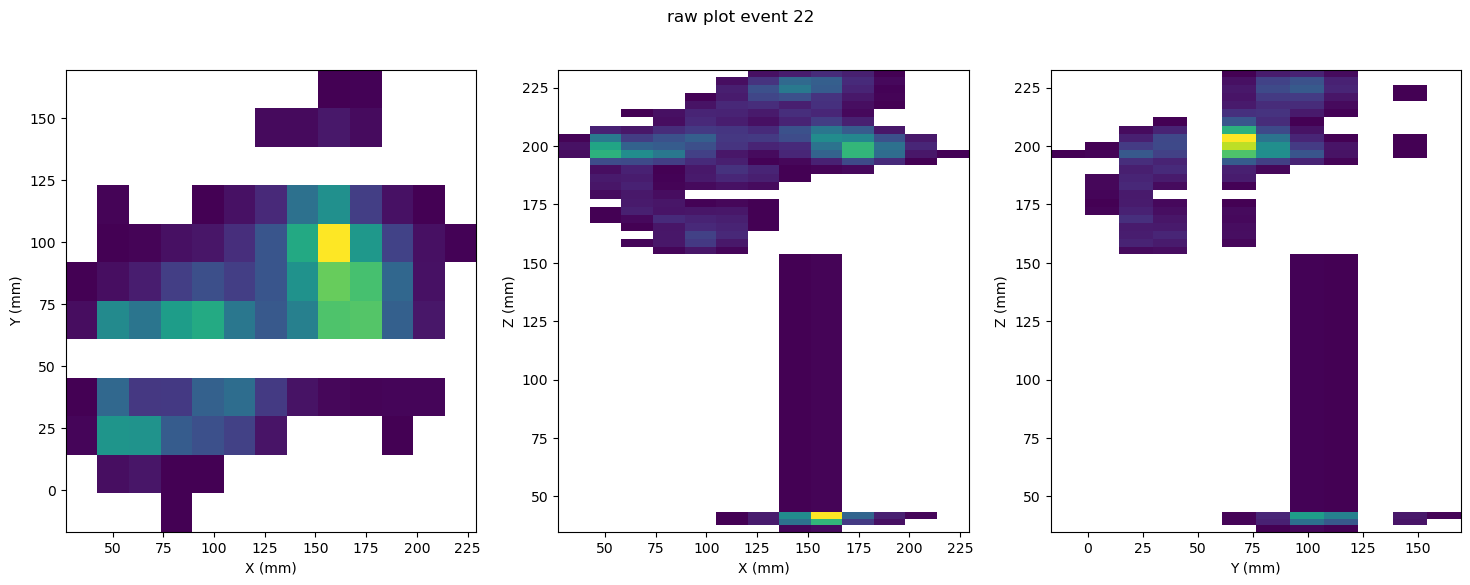

In [93]:
# sanity check
N = 19
EOI = data[data.event == data.event.unique()[N]]
display(EOI)
raw_plotter(EOI, EOI.event.unique()[0])

In [88]:
# apply standard prescription beersheba
# Parameters involved in beersheba city and the deconvolution.
nhits = 3
deconv_params = dict(
  q_cut            = 5, #5 for 6mm  - 5 for 6mm
  drop_dist        = [16, 16],#, 4],
  #psf_fname        = f'/Users/halmamol/NEXT/PSF_FLEX100_mask{dist}_lowQE.h5',     
  psf_fname        = psf_path,     
  e_cut            = 1e-9, #15 for 6mm  - 15 for 6mm
  n_iterations     = 150, #150 for 6mm  - 150 for 6mm
  iteration_tol    =  1e-10,
  sample_width     = [15.55, 15.55],
  bin_size         = [ 1,  1],
  diffusion        = (1., 1.),
  n_dim            = 2,
  deconv_mode      = DeconvolutionMode.joint,
  cut_type         = CutType.abs,
  energy_type      = HitEnergy.Ec,
  satellite_params = dict(satellite_start_iter = 20, satellite_max_size = 4, e_cut = 8e-3))#,

deconv_params_   = {k : v for k, v in deconv_params.items() if k not in ['q_cut', 'drop_dist']}

# Couple of functions used in beersheba.

cut_sensors       = cut_over_Q   (deconv_params['q_cut'    ], ['E', 'Ec'])
drop_sensors      = drop_isolated(deconv_params['drop_dist'], ['E', 'Ec'], nhits)


#deconvolve = deconvolve_signal(DataSiPM(detector_db, run_number))

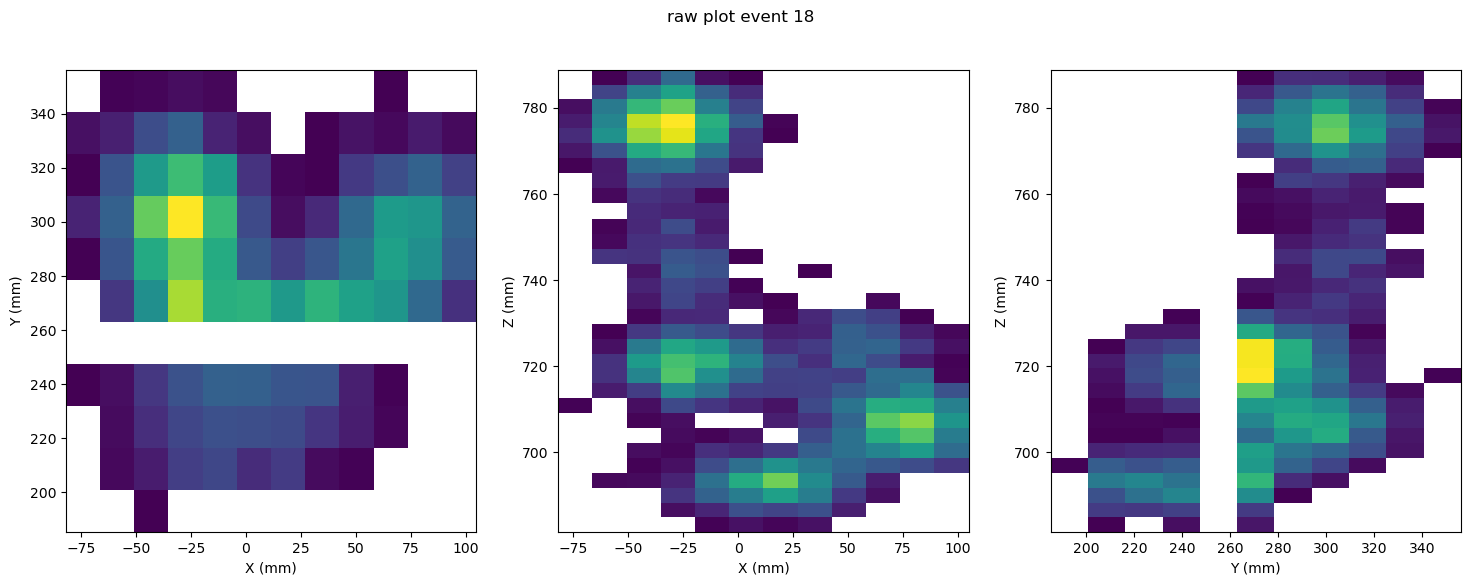

In [80]:
EOI_cut = cut_sensors(EOI)
EOI_drop = drop_sensors(EOI_cut)

raw_plotter(EOI_drop, EOI_drop.event.unique()[0])

In [81]:
# create beersheba object
detector_db = '/gluster/data/next/software/IC_john/IC/invisible_cities/database/localdb.NEXT100DB.sqlite3'
run_number = 0 
deconvolver = deconvolve_signal(DataSiPM(detector_db, run_number), **deconv_params_)

In [82]:
EOI_deco = deconvolver(EOI_drop)

In [83]:
display(EOI_deco)

,event,npeak,X,Y,Z,E,Xpeak,Ypeak
0,18,0,-24.625,217.075,681.527767,7.970692e-09,0.2371,255.611907
1,18,0,-24.625,218.075,681.527767,8.368767e-09,0.2371,255.611907
2,18,0,-24.625,219.075,681.527767,6.340296e-09,0.2371,255.611907
3,18,0,-23.625,214.075,681.527767,7.331222e-09,0.2371,255.611907
4,18,0,-23.625,215.075,681.527767,2.352194e-08,0.2371,255.611907
...,...,...,...,...,...,...,...,...
69228,18,0,-21.625,309.075,788.788708,9.164897e-09,0.2371,255.611907
69229,18,0,-21.625,310.075,788.788708,1.120492e-08,0.2371,255.611907
69230,18,0,-21.625,311.075,788.788708,1.126298e-08,0.2371,255.611907
69231,18,0,-21.625,312.075,788.788708,9.288268e-09,0.2371,255.611907


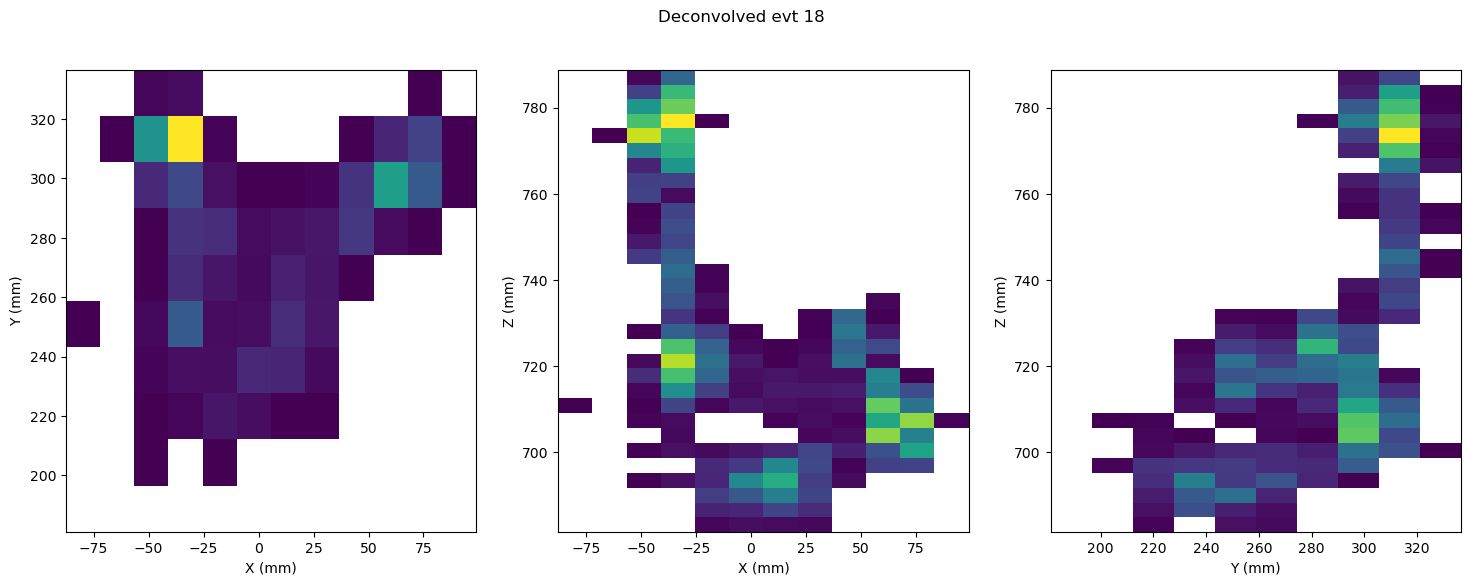

In [84]:
raw_plotter(EOI_deco, EOI_deco.event.unique()[0], param = 'E', title = f'Deconvolved evt {EOI_deco.event.unique()[0]}')

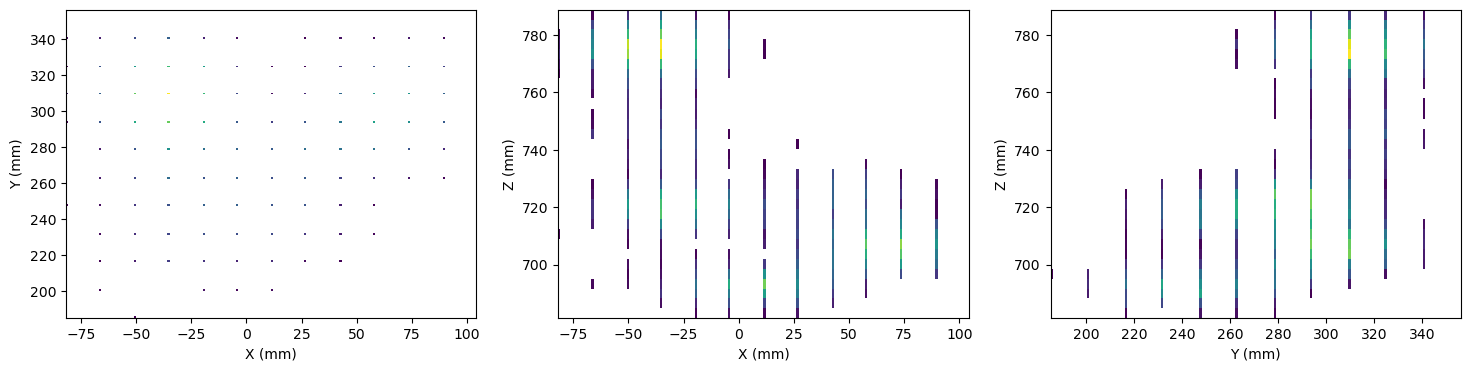

In [72]:
datatype = 'DATA'
pitch = 15.55

# plot direct comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

xx = np.arange(EOI_drop.X.min(), EOI_drop.X.max())# + pitch, pitch)
yy = np.arange(EOI_drop.Y.min(), EOI_drop.Y.max())# + pitch, pitch)
zz = EOI_drop.Z.unique()

axes[0].hist2d(EOI_drop.X, EOI_drop.Y, bins=[xx, yy], weights=EOI_drop.Q, cmin = 0.0001);
if (datatype == 'MC'):
    axes[0].scatter(xt, yt,  alpha=0.1, color='red')
axes[0].set_xlabel('X (mm)');
axes[0].set_ylabel('Y (mm)');

axes[1].hist2d(EOI_drop.X, EOI_drop.Z, bins=[xx, zz], weights=EOI_drop.Q, cmin=0.0001);
if (datatype == 'MC'):
    axes[1].scatter(xt, zt,  alpha=0.1, color='red')
axes[1].set_xlabel('X (mm)');
axes[1].set_ylabel('Z (mm)');

axes[2].hist2d(EOI_drop.Y, EOI_drop.Z, bins=[yy, zz], weights=EOI_drop.Q, cmin=0.0001);
if (datatype == 'MC'):
    axes[2].scatter(yt, zt,  alpha=0.1, color='red')
axes[2].set_xlabel('Y (mm)');
axes[2].set_ylabel('Z (mm)');

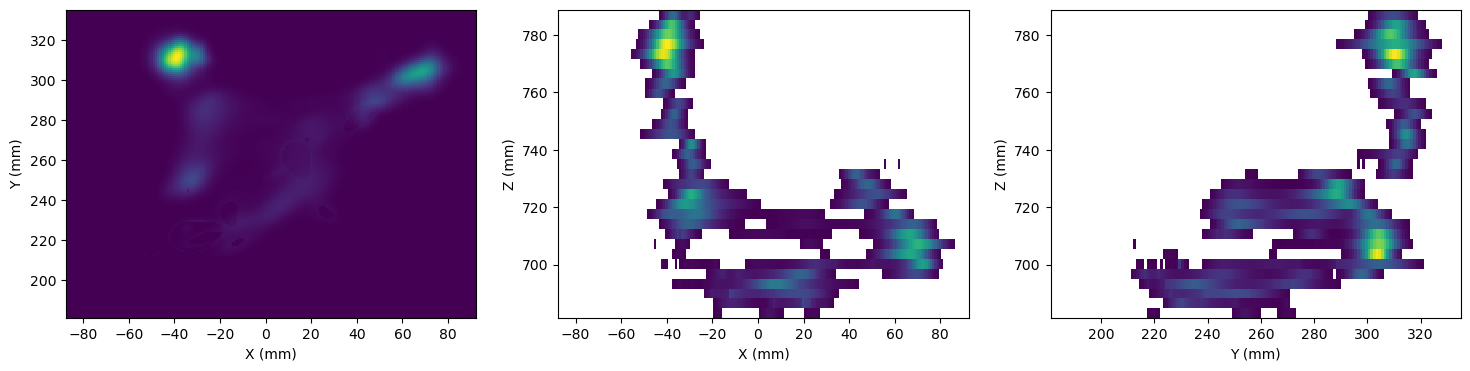

In [85]:
# plot direct comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

xx = np.arange(EOI_deco.X.min(), EOI_deco.X.max())# + pitch, pitch)
yy = np.arange(EOI_deco.Y.min(), EOI_deco.Y.max())# + pitch, pitch)
zz = EOI_deco.Z.unique()

axes[0].hist2d(EOI_deco.X, EOI_deco.Y, bins=[xx, yy], weights=EOI_deco.E);
if (datatype == 'MC'):
    axes[0].scatter(xt, yt,  alpha=0.1, color='red')
axes[0].set_xlabel('X (mm)');
axes[0].set_ylabel('Y (mm)');

axes[1].hist2d(EOI_deco.X, EOI_deco.Z, bins=[xx, zz], weights=EOI_deco.E, cmin=0.0001);
if (datatype == 'MC'):
    axes[1].scatter(xt, zt,  alpha=0.1, color='red')
axes[1].set_xlabel('X (mm)');
axes[1].set_ylabel('Z (mm)');

axes[2].hist2d(EOI_deco.Y, EOI_deco.Z, bins=[yy, zz], weights=EOI_deco.E, cmin=0.0001);
if (datatype == 'MC'):
    axes[2].scatter(yt, zt,  alpha=0.1, color='red')
axes[2].set_xlabel('Y (mm)');
axes[2].set_ylabel('Z (mm)');

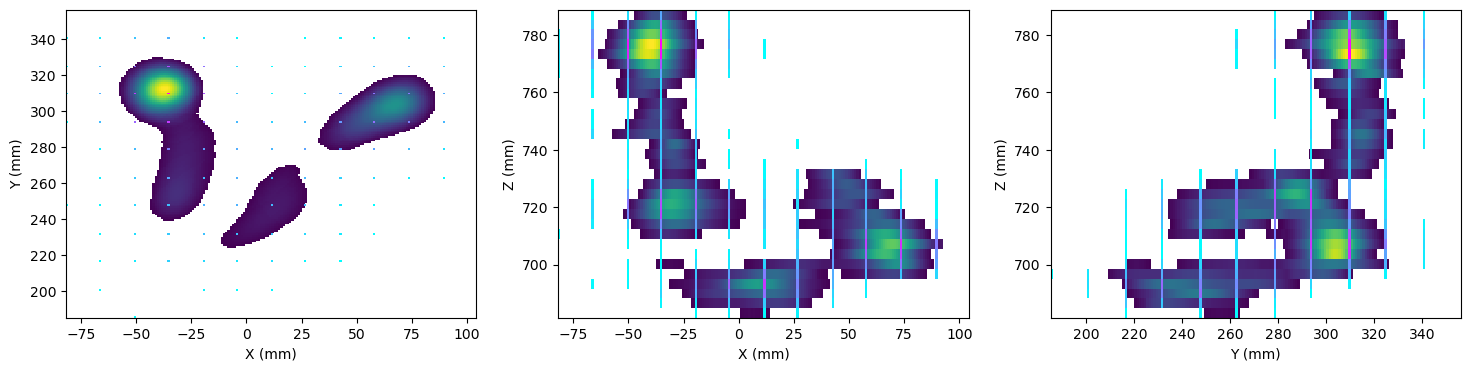

In [74]:
# plot direct comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

xx = np.arange(EOI_deco.X.min(), EOI_deco.X.max())# + pitch, pitch)
yy = np.arange(EOI_deco.Y.min(), EOI_deco.Y.max())# + pitch, pitch)
zz = EOI_deco.Z.unique()

axes[0].hist2d(EOI_deco.X, EOI_deco.Y, bins=[xx, yy], weights=EOI_deco.E, cmin = 0.0001);
if (datatype == 'MC'):
    axes[0].scatter(xt, yt,  alpha=0.1, color='red')
axes[0].set_xlabel('X (mm)');
axes[0].set_ylabel('Y (mm)');

axes[1].hist2d(EOI_deco.X, EOI_deco.Z, bins=[xx, zz], weights=EOI_deco.E, cmin=0.0001);
if (datatype == 'MC'):
    axes[1].scatter(xt, zt,  alpha=0.1, color='red')
axes[1].set_xlabel('X (mm)');
axes[1].set_ylabel('Z (mm)');

axes[2].hist2d(EOI_deco.Y, EOI_deco.Z, bins=[yy, zz], weights=EOI_deco.E, cmin=0.0001);
if (datatype == 'MC'):
    axes[2].scatter(yt, zt,  alpha=0.1, color='red')
axes[2].set_xlabel('Y (mm)');
axes[2].set_ylabel('Z (mm)');

xx = np.arange(EOI_drop.X.min(), EOI_drop.X.max())# + pitch, pitch)
yy = np.arange(EOI_drop.Y.min(), EOI_drop.Y.max())# + pitch, pitch)
zz = EOI_drop.Z.unique()

axes[0].hist2d(EOI_drop.X, EOI_drop.Y, bins=[xx, yy], weights=EOI_drop.Q, cmin = 0.0001, cmap = 'cool');
if (datatype == 'MC'):
    axes[0].scatter(xt, yt,  alpha=0.1, color='red')
axes[0].set_xlabel('X (mm)');
axes[0].set_ylabel('Y (mm)');

axes[1].hist2d(EOI_drop.X, EOI_drop.Z, bins=[xx, zz], weights=EOI_drop.Q, cmin=0.0001, cmap = 'cool');
if (datatype == 'MC'):
    axes[1].scatter(xt, zt,  alpha=0.1, color='red')
axes[1].set_xlabel('X (mm)');
axes[1].set_ylabel('Z (mm)');

axes[2].hist2d(EOI_drop.Y, EOI_drop.Z, bins=[yy, zz], weights=EOI_drop.Q, cmin=0.0001, cmap = 'cool');
if (datatype == 'MC'):
    axes[2].scatter(yt, zt,  alpha=0.1, color='red')
axes[2].set_xlabel('Y (mm)');
axes[2].set_ylabel('Z (mm)');

fig.show()

In [89]:
from pathlib import Path
from datetime import datetime# generate output folder
global_timestamp = datetime.now().strftime("%H%M%S_%Y%m%d")
folder = f'gif_images/{global_timestamp}'
path = Path(folder)
path.mkdir(parents=True, exist_ok = True)
print(f'Generated folder {path}')

# for gif creation
png_list = []

n_iterations_max = 200 
iteration_step   = 10
for i in range(10, n_iterations_max, iteration_step):
    print(i)
    deconv_params_['n_iterations'] = i
    deconvolver = deconvolve_signal(DataSiPM(detector_db, run_number), **deconv_params_)
    EOI_deco = deconvolver(EOI_drop)
    
    # plot direct comparison
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    xx = np.arange(EOI_deco.X.min(), EOI_deco.X.max())# + pitch, pitch)
    yy = np.arange(EOI_deco.Y.min(), EOI_deco.Y.max())# + pitch, pitch)
    zz = EOI_deco.Z.unique()

    axes[0].hist2d(EOI_deco.X, EOI_deco.Y, bins=[xx, yy], weights=EOI_deco.E, cmin = 0.0001);
    if (datatype == 'MC'):
        axes[0].scatter(xt, yt,  alpha=0.1, color='red')
    axes[0].set_xlabel('X (mm)');
    axes[0].set_ylabel('Y (mm)');

    axes[1].hist2d(EOI_deco.X, EOI_deco.Z, bins=[xx, zz], weights=EOI_deco.E, cmin=0.0001);
    if (datatype == 'MC'):
        axes[1].scatter(xt, zt,  alpha=0.1, color='red')
    axes[1].set_xlabel('X (mm)');
    axes[1].set_ylabel('Z (mm)');

    axes[2].hist2d(EOI_deco.Y, EOI_deco.Z, bins=[yy, zz], weights=EOI_deco.E, cmin=0.0001);
    if (datatype == 'MC'):
        axes[2].scatter(yt, zt,  alpha=0.1, color='red')
    axes[2].set_xlabel('Y (mm)');
    axes[2].set_ylabel('Z (mm)');

    xx = np.arange(EOI_drop.X.min(), EOI_drop.X.max())# + pitch, pitch)
    yy = np.arange(EOI_drop.Y.min(), EOI_drop.Y.max())# + pitch, pitch)
    zz = EOI_drop.Z.unique()

    axes[0].hist2d(EOI_drop.X, EOI_drop.Y, bins=[xx, yy], weights=EOI_drop.Q, cmin = 0.0001, cmap = 'cool');
    if (datatype == 'MC'):
        axes[0].scatter(xt, yt,  alpha=0.1, color='red')
    axes[0].set_xlabel('X (mm)');
    axes[0].set_ylabel('Y (mm)');

    axes[1].hist2d(EOI_drop.X, EOI_drop.Z, bins=[xx, zz], weights=EOI_drop.Q, cmin=0.0001, cmap = 'cool');
    if (datatype == 'MC'):
        axes[1].scatter(xt, zt,  alpha=0.1, color='red')
    axes[1].set_xlabel('X (mm)');
    axes[1].set_ylabel('Z (mm)');

    axes[2].hist2d(EOI_drop.Y, EOI_drop.Z, bins=[yy, zz], weights=EOI_drop.Q, cmin=0.0001, cmap = 'cool');
    if (datatype == 'MC'):
        axes[2].scatter(yt, zt,  alpha=0.1, color='red')
    axes[2].set_xlabel('Y (mm)');
    axes[2].set_ylabel('Z (mm)');
    fig.suptitle(f'iteration_{i}')
    plt.savefig(f'{path}/iter_{i}.png')
    png_list.append(f'{path}/iter_{i}.png')
    plt.close()

Generated folder gif_images/184402_20260323
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190


In [90]:
import imageio.v2 as imageio


with imageio.get_writer(f"gif_images/{global_timestamp}.gif", mode="I", duration=1, loop = 0) as writer:
    for file in png_list:
        writer.append_data(imageio.imread(file))

### trying with the q_cut = 2 pes psf

In [96]:
PSF_2PEs = '/gluster/data/next/files/TOPOLOGY_John/N100_data/15616/prod_psf/eutropia/040925/merged_psfs/final/040925_full_25us.psf'
deconv_params_['psf_fname'] = PSF_2PEs

from pathlib import Path
from datetime import datetime# generate output folder
global_timestamp = datetime.now().strftime("%H%M%S_%Y%m%d")
folder = f'gif_images/{global_timestamp}'
path = Path(folder)
path.mkdir(parents=True, exist_ok = True)
print(f'Generated folder {path}')

# for gif creation
png_list = []

n_iterations_max = 601
iteration_step   = 30
for i in range(30, n_iterations_max, iteration_step):
    print(i)
    deconv_params_['n_iterations'] = i
    deconvolver = deconvolve_signal(DataSiPM(detector_db, run_number), **deconv_params_)
    EOI_deco = deconvolver(EOI_drop)
    
    # plot direct comparison
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    xx = np.arange(EOI_deco.X.min(), EOI_deco.X.max())# + pitch, pitch)
    yy = np.arange(EOI_deco.Y.min(), EOI_deco.Y.max())# + pitch, pitch)
    zz = EOI_deco.Z.unique()

    axes[0].hist2d(EOI_deco.X, EOI_deco.Y, bins=[xx, yy], weights=EOI_deco.E, cmin = 0.0001);
    if (datatype == 'MC'):
        axes[0].scatter(xt, yt,  alpha=0.1, color='red')
    axes[0].set_xlabel('X (mm)');
    axes[0].set_ylabel('Y (mm)');

    axes[1].hist2d(EOI_deco.X, EOI_deco.Z, bins=[xx, zz], weights=EOI_deco.E, cmin=0.0001);
    if (datatype == 'MC'):
        axes[1].scatter(xt, zt,  alpha=0.1, color='red')
    axes[1].set_xlabel('X (mm)');
    axes[1].set_ylabel('Z (mm)');

    axes[2].hist2d(EOI_deco.Y, EOI_deco.Z, bins=[yy, zz], weights=EOI_deco.E, cmin=0.0001);
    if (datatype == 'MC'):
        axes[2].scatter(yt, zt,  alpha=0.1, color='red')
    axes[2].set_xlabel('Y (mm)');
    axes[2].set_ylabel('Z (mm)');

    xx = np.arange(EOI_drop.X.min()-pitch, EOI_drop.X.max()+pitch)# + pitch, pitch)
    yy = np.arange(EOI_drop.Y.min()-pitch, EOI_drop.Y.max()+pitch)# + pitch, pitch)
    zz = EOI_drop.Z.unique()

    axes[0].hist2d(EOI_drop.X, EOI_drop.Y, bins=[xx, yy], weights=EOI_drop.Q, cmin = 0.0001, cmap = 'cool');
    if (datatype == 'MC'):
        axes[0].scatter(xt, yt,  alpha=0.1, color='red')
    axes[0].set_xlabel('X (mm)');
    axes[0].set_ylabel('Y (mm)');

    axes[1].hist2d(EOI_drop.X, EOI_drop.Z, bins=[xx, zz], weights=EOI_drop.Q, cmin=0.0001, cmap = 'cool');
    if (datatype == 'MC'):
        axes[1].scatter(xt, zt,  alpha=0.1, color='red')
    axes[1].set_xlabel('X (mm)');
    axes[1].set_ylabel('Z (mm)');

    axes[2].hist2d(EOI_drop.Y, EOI_drop.Z, bins=[yy, zz], weights=EOI_drop.Q, cmin=0.0001, cmap = 'cool');
    if (datatype == 'MC'):
        axes[2].scatter(yt, zt,  alpha=0.1, color='red')
    axes[2].set_xlabel('Y (mm)');
    axes[2].set_ylabel('Z (mm)');
    fig.suptitle(f'iteration_{i} w/ 15616 (2 PEs) PSF')
    plt.savefig(f'{path}/iter_{i}.png')
    png_list.append(f'{path}/iter_{i}.png')
    plt.close()

Generated folder gif_images/170220_20260302
30
60
90
120
150
180
210
240
270
300
330
360
390
420
450
480
510
540
570
600


In [97]:
import imageio.v2 as imageio


with imageio.get_writer(f"gif_images/{global_timestamp}.gif", mode="I", duration=1, loop = 0) as writer:
    for file in png_list:
        writer.append_data(imageio.imread(file))

### load in 15539 one bin data

In [98]:
kr_data_path = '/gluster/data/next/files/TOPOLOGY_John/N100_data/15539/sophronia/run_15539_0001_ldc1_trg1.sophronia_1PEs.h5'
kr_data = load_dst(kr_data_path, 'RECO', 'Events')

In [99]:
# load in krypton map relevant to these events
# here we're going to use the krypton map that assumes no thresholds 
PSF_noPES = '/gluster/data/next/files/TOPOLOGY_John/N100_data/15539/eutropia/PSF_15539_z100_xy1.0_130125.psf'

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,Z,Q,E,Qc,Ec,track_id,Ep
694,2045,1.750084e+09,0,-77.330762,35.153424,1,-404.875,-263.725,0.0,0.0,64.508997,2.947154,17.255095,-1.0,-1.0,-1,-1.0
695,2045,1.750084e+09,0,-77.330762,35.153424,1,-482.625,-124.775,0.0,0.0,64.508997,2.888913,16.914104,-1.0,-1.0,-1,-1.0
696,2045,1.750084e+09,0,-77.330762,35.153424,1,-420.425,-62.575,0.0,0.0,64.508997,2.334365,13.667318,-1.0,-1.0,-1,-1.0
697,2045,1.750084e+09,0,-77.330762,35.153424,1,-389.325,-62.575,0.0,0.0,64.508997,2.115768,12.387468,-1.0,-1.0,-1,-1.0
698,2045,1.750084e+09,0,-77.330762,35.153424,1,-373.775,-155.875,0.0,0.0,64.508997,2.089278,12.232373,-1.0,-1.0,-1,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
962,2045,1.750084e+09,0,-77.330762,35.153424,1,381.175,214.325,0.0,0.0,64.508997,2.073942,12.142586,-1.0,-1.0,-1,-1.0
963,2045,1.750084e+09,0,-77.330762,35.153424,1,396.725,307.625,0.0,0.0,64.508997,3.763338,22.033718,-1.0,-1.0,-1,-1.0
964,2045,1.750084e+09,0,-77.330762,35.153424,1,443.375,198.775,0.0,0.0,64.508997,2.914721,17.065206,-1.0,-1.0,-1,-1.0
965,2045,1.750084e+09,0,-77.330762,35.153424,1,474.475,214.325,0.0,0.0,64.508997,2.188171,12.811378,-1.0,-1.0,-1,-1.0


/tmp/ipykernel_1499404/3337667901.py:42: UserWarning: Attempting to set identical bottom == top == 64.508996875 results in singular transformations; automatically expanding.
  axes[1].hist2d(q.X, q.Z, bins=[xx, zz], weights=q[param], cmin=0.0001);
/tmp/ipykernel_1499404/3337667901.py:47: UserWarning: Attempting to set identical bottom == top == 64.508996875 results in singular transformations; automatically expanding.
  axes[2].hist2d(q.Y, q.Z, bins=[yy, zz], weights=q[param], cmin=0.0001);


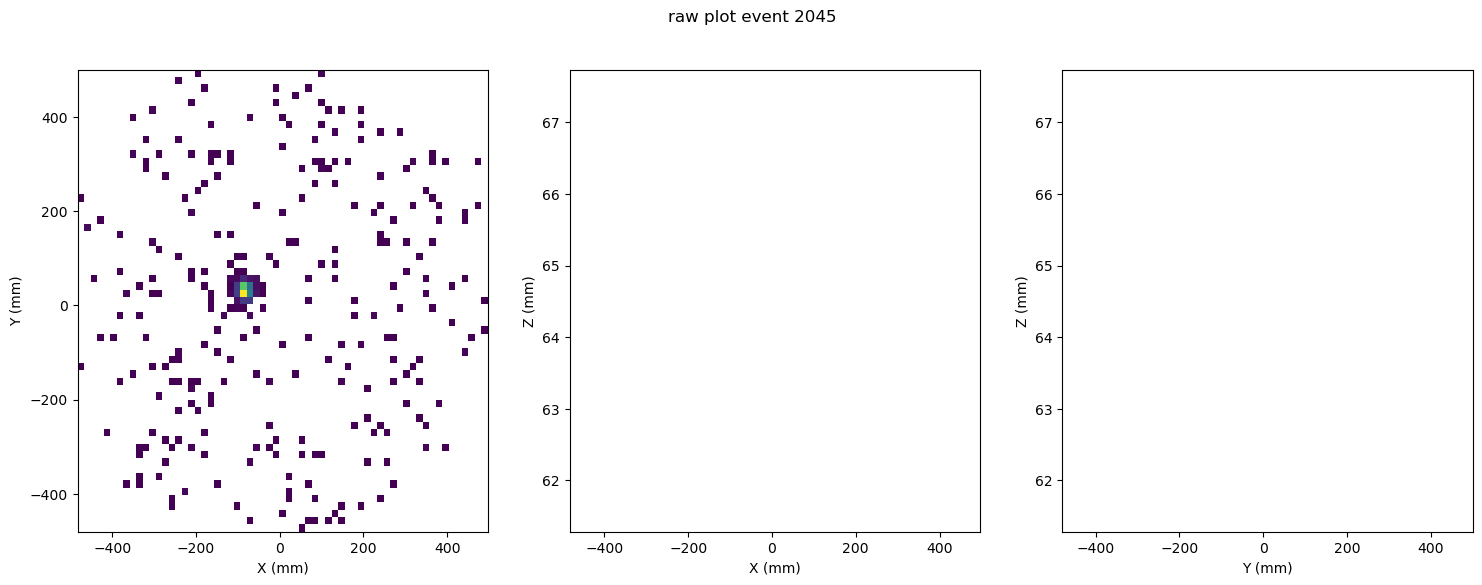

In [104]:
# sanity check
N = 2
EOI = kr_data[kr_data.event == kr_data.event.unique()[N]]
display(EOI)
raw_plotter(EOI, EOI.event.unique()[0])

In [133]:
# apply standard prescription beersheba
# Parameters involved in beersheba city and the deconvolution.
nhits = 3
deconv_params = dict(
  q_cut            = 5, #5 for 6mm  - 5 for 6mm
  drop_dist        = [16, 16],#, 4],
  #psf_fname        = f'/Users/halmamol/NEXT/PSF_FLEX100_mask{dist}_lowQE.h5',     
  psf_fname        = PSF_noPES,     
  e_cut            = 8e-3, #15 for 6mm  - 15 for 6mm
  n_iterations     = 25, #150 for 6mm  - 150 for 6mm
  iteration_tol    =  1e-10,
  sample_width     = [15.55, 15.55],
  bin_size         = [ 1,  1],
  diffusion        = (1., 1.),
  n_dim            = 2,
  deconv_mode      = DeconvolutionMode.joint,
  cut_type         = CutType.abs,
  energy_type      = HitEnergy.Ec,
  satellite_params = dict(satellite_start_iter = 20, satellite_max_size = 4, e_cut = 8e-3))#,

deconv_params_   = {k : v for k, v in deconv_params.items() if k not in ['q_cut', 'drop_dist']}

# Couple of functions used in beersheba.

cut_sensors       = cut_over_Q   (deconv_params['q_cut'    ], ['E', 'Ec'])
drop_sensors      = drop_isolated(deconv_params['drop_dist'], ['E', 'Ec'], nhits)


#deconvolve = deconvolve_signal(DataSiPM(detector_db, run_number))

/tmp/ipykernel_1499404/3337667901.py:42: UserWarning: Attempting to set identical bottom == top == 64.508996875 results in singular transformations; automatically expanding.
  axes[1].hist2d(q.X, q.Z, bins=[xx, zz], weights=q[param], cmin=0.0001);
/tmp/ipykernel_1499404/3337667901.py:47: UserWarning: Attempting to set identical bottom == top == 64.508996875 results in singular transformations; automatically expanding.
  axes[2].hist2d(q.Y, q.Z, bins=[yy, zz], weights=q[param], cmin=0.0001);


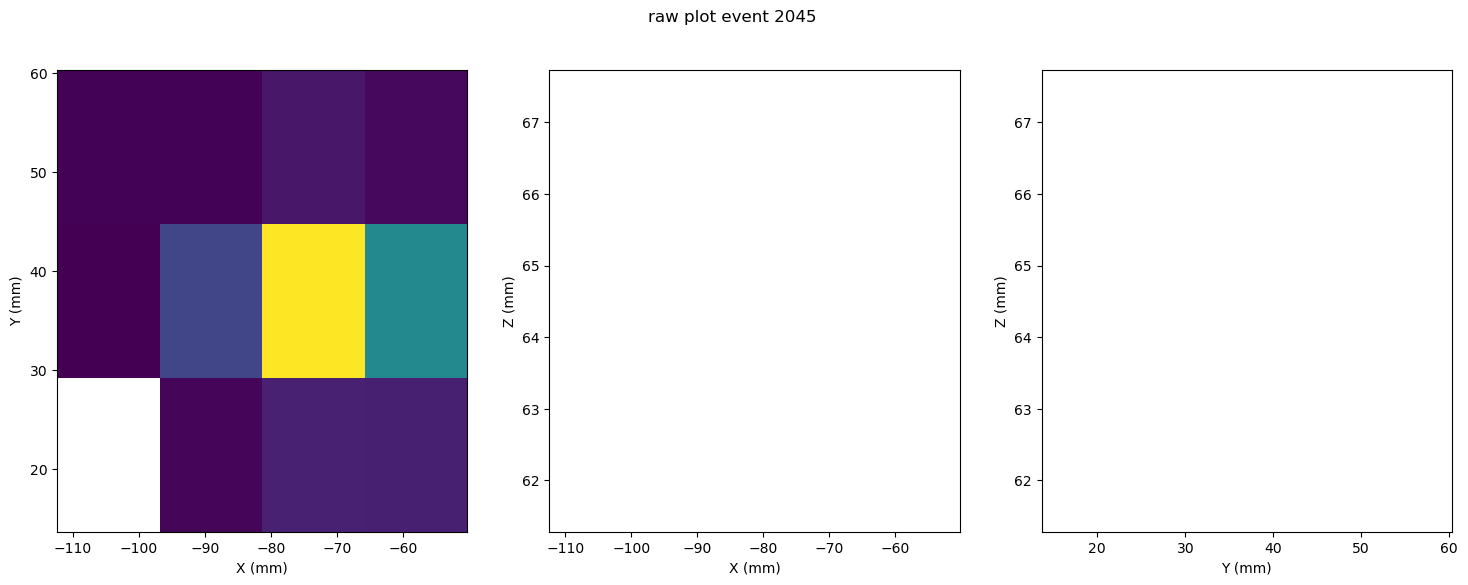

In [134]:
EOI_cut = cut_sensors(EOI)
EOI_drop = drop_sensors(EOI_cut)

raw_plotter(EOI_drop, EOI_drop.event.unique()[0])

In [138]:
from pathlib import Path
from datetime import datetime# generate output folder
global_timestamp = datetime.now().strftime("%H%M%S_%Y%m%d")
folder = f'gif_images/{global_timestamp}'
path = Path(folder)
path.mkdir(parents=True, exist_ok = True)
print(f'Generated folder {path}')

# for gif creation
png_list = []

n_iterations_max = 601
iteration_step   = 30
for i in range(30, n_iterations_max, iteration_step):
    print(i)
    deconv_params_['n_iterations'] = i
    deconvolver = deconvolve_signal(DataSiPM(detector_db, run_number), **deconv_params_)
    EOI_deco = deconvolver(EOI_drop)
    
    # plot direct comparison
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    xx = np.arange(EOI_deco.X.min(), EOI_deco.X.max())# + pitch, pitch)
    yy = np.arange(EOI_deco.Y.min(), EOI_deco.Y.max())# + pitch, pitch)
    zz = EOI_deco.Z.unique()
    
    EOI_deco.E = np.abs(EOI_deco.E)
    axes[0].hist2d(EOI_deco.X, EOI_deco.Y, bins=[xx, yy], weights=EOI_deco.E, cmin = 0.0001);
    if (datatype == 'MC'):
        axes[0].scatter(xt, yt,  alpha=0.1, color='red')
    axes[0].set_xlabel('X (mm)');
    axes[0].set_ylabel('Y (mm)');

    #axes[1].hist2d(EOI_deco.X, EOI_deco.Z, bins=[xx, zz], weights=EOI_deco.E, cmin=0.0001);
    #if (datatype == 'MC'):
    #    axes[1].scatter(xt, zt,  alpha=0.1, color='red')
    #axes[1].set_xlabel('X (mm)');
    #axes[1].set_ylabel('Z (mm)');

    #axes[2].hist2d(EOI_deco.Y, EOI_deco.Z, bins=[yy, zz], weights=EOI_deco.E, cmin=0.0001);
    #if (datatype == 'MC'):
    #    axes[2].scatter(yt, zt,  alpha=0.1, color='red')
    #axes[2].set_xlabel('Y (mm)');
    #axes[2].set_ylabel('Z (mm)');

    xx = np.arange(EOI_drop.X.min(), EOI_drop.X.max())# + pitch, pitch)
    yy = np.arange(EOI_drop.Y.min(), EOI_drop.Y.max())# + pitch, pitch)
    zz = EOI_drop.Z.unique()

    axes[0].hist2d(EOI_drop.X, EOI_drop.Y, bins=[xx, yy], weights=EOI_drop.Q, cmin = 0.0001, cmap = 'cool');
    if (datatype == 'MC'):
        axes[0].scatter(xt, yt,  alpha=0.1, color='red')
    axes[0].set_xlabel('X (mm)');
    axes[0].set_ylabel('Y (mm)');

    #axes[1].hist2d(EOI_drop.X, EOI_drop.Z, bins=[xx, zz], weights=EOI_drop.Q, cmin=0.0001, cmap = 'cool');
    #if (datatype == 'MC'):
    #    axes[1].scatter(xt, zt,  alpha=0.1, color='red')
    #axes[1].set_xlabel('X (mm)');
    #axes[1].set_ylabel('Z (mm)');

    #axes[2].hist2d(EOI_drop.Y, EOI_drop.Z, bins=[yy, zz], weights=EOI_drop.Q, cmin=0.0001, cmap = 'cool');
    #if (datatype == 'MC'):
    #    axes[2].scatter(yt, zt,  alpha=0.1, color='red')
    #axes[2].set_xlabel('Y (mm)');
    #axes[2].set_ylabel('Z (mm)');
    fig.suptitle(f'iteration_{i} rebinned in Z')
    plt.savefig(f'{path}/iter_{i}.png')
    png_list.append(f'{path}/iter_{i}.png')
    plt.close()

Generated folder gif_images/172235_20260302
30
60
90
120
150
180
210
240
270
300
330
360
390
420
450
480
510
540
570
600


In [139]:
import imageio.v2 as imageio


with imageio.get_writer(f"gif_images/{global_timestamp}.gif", mode="I", duration=1, loop = 0) as writer:
    for file in png_list:
        writer.append_data(imageio.imread(file))

In [140]:
display(EOI_deco)

,event,npeak,X,Y,Z,E,Xpeak,Ypeak
0,2045,0,-82.625,34.075,64.508997,0.015980,-77.330762,35.153424
1,2045,0,-82.625,35.075,64.508997,0.025852,-77.330762,35.153424
2,2045,0,-82.625,36.075,64.508997,0.032270,-77.330762,35.153424
3,2045,0,-82.625,37.075,64.508997,0.031983,-77.330762,35.153424
4,2045,0,-82.625,38.075,64.508997,0.025598,-77.330762,35.153424
...,...,...,...,...,...,...,...,...
121,2045,0,-73.625,31.075,64.508997,0.036932,-77.330762,35.153424
122,2045,0,-73.625,32.075,64.508997,0.037542,-77.330762,35.153424
123,2045,0,-73.625,33.075,64.508997,0.030183,-77.330762,35.153424
124,2045,0,-73.625,34.075,64.508997,0.020205,-77.330762,35.153424
